# Stage 5 — Transpilation

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `04_classical_training.ipynb`
**Next:** → `06_hardware_retuning.ipynb`

---

Every stage so far has treated the circuit as an idealized mathematical object — any qubit can talk to any other qubit, any rotation angle is available natively. Real hardware has neither property. This notebook takes the trained circuit from Stage 4 and rewrites it to survive contact with a realistic, connectivity-limited device — the last purely *structural* step before hardware noise itself enters the picture in Stage 6.


## 1. What Is Transpilation? (General Overview)

**Transpilation** is the process of rewriting a quantum circuit written for an idealized model of computation into an equivalent circuit that a specific target device can actually run. It's the quantum analogue of a classical compiler lowering source code to a specific CPU's instruction set — except here, the "instruction set" constraint is joined by a second, purely physical constraint that classical compilers never face.

Two independent problems get solved during transpilation:

1. **Basis-gate translation** — real hardware only implements a small, fixed set of native gates (for example, single-qubit $R_z$ and $\sqrt{X}$ rotations, plus one two-qubit gate like CNOT or CZ). Gates used at the algorithm level — our $R_y(\theta)$ rotations and controlled-$R_y$ gates — don't exist natively and must be decomposed into sequences of native gates that reproduce the same unitary.

2. **Layout and routing** — a real chip's qubits are wired together in a fixed physical pattern (a "coupling map"), and a two-qubit gate can usually only be applied directly between qubits that are physically connected. If the circuit needs a two-qubit gate between two *logical* qubits that aren't adjacent on the *physical* chip, extra **SWAP gates** must be inserted to physically move the relevant quantum information until it lands on connected qubits — a decision problem, not a fixed conversion, since there are usually many valid ways to do this, of wildly different cost.


## 2. Why We Do This Here

1. **The trained circuit from Stage 4 assumes a fully-connected, arbitrary-gate machine — no real device works that way.** The base paper's own hardware (a 17-qubit superconducting processor, Contralto-D) has fixed nearest-neighbor-style connectivity and a small native gate set (single-qubit $X/Y$ rotations via microwave pulses, plus a native CZ two-qubit gate). Before Stage 6 can talk about "hardware noise," Stage 5 first has to answer a *structural* question: does our circuit even fit on a device shaped like that, and at what cost?

2. **It's a prerequisite gap, not a detail.** Recall the base paper's own finding (and this project's targeted gap, from `00_overview.ipynb` §2): transpilation, done well, only guarantees a *structurally* efficient circuit — minimal depth, minimal SWAP count. It says nothing about whether that circuit will actually *behave* correctly once real gate errors are added. Stage 5 produces the "well-transpiled but not yet noise-aware" circuit; Stage 6 is where that distinction becomes concrete.

3. **It's where SABRE — a gap-critical algorithm named explicitly in the base paper — actually runs.** Stage 00's gap analysis calls out SABRE by name as a *structure-only* optimizer. This notebook is the first place SABRE is actually used, so that claim can be checked directly rather than taken on faith.


## 3. Where This Fits in the Project Pipeline

This is **Stage 5 of 9**. Inputs and outputs:

- **Input:** the trained rotation angles $\theta_0^*,\dots,\theta_{n-1}^*$ from `04_classical_training.ipynb`, and the fixed asset-encoding parameters $\tilde\alpha,\tilde\beta$ from `02_quantum_encoding.ipynb` / `03_circuit_design.ipynb`.
- **Output:** a **transpiled** circuit — expressed in a realistic native gate set, laid out and routed onto a connectivity-limited mock device — for both the 2-qubit and 3-qubit z-register cases. This is the circuit Stage 6 will attempt to retune under simulated noise, and Stage 7 will actually execute.


## 4. Key Concepts

### 4.1 Coupling maps

A **coupling map** is simply the list of which physical qubit pairs are allowed to interact directly with a two-qubit gate — equivalently, a graph where nodes are qubits and edges are the available connections. Real chips are never fully connected (that requires wiring that doesn't scale); common shapes include linear chains, 2D grids, and more specialized layouts like the base paper's device. If a two-qubit gate is needed between two *non-adjacent* qubits, the transpiler must insert SWAP gates to relocate the relevant state until the pair becomes adjacent — and each SWAP itself compiles down to **three** additional two-qubit gates, each carrying real error.

### 4.2 SABRE (SWAP-based Bidirectional heuristic search)

SABRE is the routing/layout algorithm used both by the base paper and by this project (via Qiskit's built-in implementation). In plain terms: it picks an initial mapping of logical qubits onto physical qubits, then walks forward through the circuit's gates; whenever it hits a gate between two logical qubits that aren't currently adjacent, it inserts the SWAP (or short sequence of SWAPs) that a look-ahead heuristic judges will help the *most upcoming gates at once* — not just the current one. It then repeats this in reverse (bidirectional), using the result to refine the *initial* layout choice, iterating a few times. The result is usually a good, though not provably optimal, layout+routing solution — found fast enough to be practical on every circuit compiled.

**Crucially, notice what SABRE's cost function is built from:** gate count and circuit depth (structural properties visible from the circuit alone). It has **no input describing which physical qubits or gates are more or less error-prone on the actual chip** — that information doesn't exist yet at this stage of the pipeline. This is precisely the base paper's "Offline Compilation Disconnect" gap.


## 5. Implementation

### 5.1 Rebuilding the trained circuits

We reload Stage 4's trained angles and Stage 2's encoding parameters, and bind them into concrete (fully numeric — no more `Parameter` placeholders) circuits, since a circuit heading to hardware needs fixed values, not symbolic ones.


In [1]:
import json
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit.circuit import Parameter

def load_json_safely(path, fallback_fn):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"{path} not found -- using fallback computation.")
        return fallback_fn()

# --- Stage 2/3: fixed asset-encoding parameters ---
enc = load_json_safely("quantum_encoding_params.json", lambda: None)
if enc is None:
    from scipy.stats import norm
    p0, rho, z_max = 0.25, 0.027, 3.0
    z_fit = np.linspace(-z_max, z_max, 400)
    pd_z = norm.cdf((norm.ppf(p0) - np.sqrt(rho) * z_fit) / np.sqrt(1 - rho))
    theta_fit = np.arcsin(np.sqrt(pd_z))
    alpha, beta = np.polyfit(z_fit, theta_fit, 1)
    enc = {"register_adapted": {}}
    for n in (2, 3):
        n_bins = 2 ** n
        slope = (2 * z_max) / (n_bins - 1)
        enc["register_adapted"][f"{n}_qubit"] = {
            "alpha_tilde": alpha * slope, "beta_tilde": beta - alpha * z_max
        }

# --- Stage 4: trained ansatz angles ---
trained = load_json_safely("trained_parameters.json", lambda: None)
if trained is None:
    raise RuntimeError("Run 04_classical_training.ipynb first to produce trained_parameters.json")

print("Loaded encoding parameters and trained angles.")
for n in (2, 3):
    print(f"  {n}-qubit: theta* = {trained[f'{n}_qubit']['theta']}, "
          f"alpha_tilde = {enc['register_adapted'][f'{n}_qubit']['alpha_tilde']:.4f}, "
          f"beta_tilde = {enc['register_adapted'][f'{n}_qubit']['beta_tilde']:.4f}")


quantum_encoding_params.json not found -- using fallback computation.


Loaded encoding parameters and trained angles.
  2-qubit: theta* = [1.5707221568062237, 3.4095575857081593], alpha_tilde = -0.1210, beta_tilde = 0.7055
  3-qubit: theta* = [1.5706602940738232, 0.9606948163165919, 2.286534514795309], alpha_tilde = -0.0518, beta_tilde = 0.7055


In [2]:
def build_bound_circuit(n_z_qubits, theta_values, alpha_tilde, beta_tilde):
    """The full GCI circuit (Stage 3), with the ansatz angles already bound to
    Stage 4's trained numeric values -- no symbolic Parameters remain.
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total, n_total, name=f"GCI_{n_z_qubits}q_trained")

    for i in range(n_z_qubits):
        qc.ry(theta_values[i], i)
    for i in range(1, n_z_qubits):
        qc.cx(0, i)

    qc.barrier()
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    qc.measure(range(n_total), range(n_total))
    return qc

circuits = {}
for n in (2, 3):
    theta = trained[f"{n}_qubit"]["theta"]
    a_tilde = enc["register_adapted"][f"{n}_qubit"]["alpha_tilde"]
    b_tilde = enc["register_adapted"][f"{n}_qubit"]["beta_tilde"]
    circuits[n] = build_bound_circuit(n, theta, a_tilde, b_tilde)
    print(f"{n}-qubit register -- original circuit: depth={circuits[n].depth()}, "
          f"gates={dict(circuits[n].count_ops())}")


2-qubit register -- original circuit: depth=6, gates={'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}
3-qubit register -- original circuit: depth=8, gates={'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}


### 5.2 Defining a mock hardware device

We use simple **linear-chain coupling maps** — a device where qubit $i$ can only interact directly with qubit $i{+}1$. This is the simplest possible example of "not everything is connected to everything," and it's deliberately more restrictive than our circuits' own connectivity needs — which forces the transpiler to actually do meaningful work, rather than trivially confirming a circuit that already fits.

Checking our circuits' *logical* connectivity requirements first makes clear why: the 3-qubit total circuit needs gates between **every pair** of its 3 qubits (q0–q1 from the entangler, q0–asset and q1–asset from the encoder) — a fully-connected requirement that a 4-qubit line cannot satisfy without at least one SWAP.


In [3]:
# Mock devices: simple linear chains, one qubit larger than each circuit needs
coupling_maps = {
    2: CouplingMap([[0, 1], [1, 2], [2, 3]]),        # 4-qubit line, for the 3-qubit total circuit
    3: CouplingMap([[0, 1], [1, 2], [2, 3], [3, 4]]),  # 5-qubit line, for the 4-qubit total circuit
}

for n, cmap in coupling_maps.items():
    print(f"{n}-qubit register case -- mock device has {cmap.size()} physical qubits, "
          f"edges: {list(cmap.get_edges())}")


2-qubit register case -- mock device has 4 physical qubits, edges: [(0, 1), (1, 2), (2, 3)]
3-qubit register case -- mock device has 5 physical qubits, edges: [(0, 1), (1, 2), (2, 3), (3, 4)]


### 5.3 Isolating two separate costs

Before running the full transpilation, we separate **two different sources of overhead** that are easy to conflate:

1. **Basis-gate decomposition cost** — what it costs just to express our $R_y$/CNOT/controlled-$R_y$ gates using the hardware's native gate set, *assuming* full connectivity (no coupling map restriction at all).
2. **Routing cost** — the *additional* overhead SABRE must add on top of that, purely because of the limited coupling map.

We use `['rz', 'sx', 'x', 'cz']` as the native gate set — matching the base paper's actual hardware, which implements single-qubit rotations via microwave DRAG pulses and uses a native CZ gate for two-qubit interactions.


In [4]:
NATIVE_GATES = ['rz', 'sx', 'x', 'cz']

decomposition_only = {}
full_transpilation = {}

for n in (2, 3):
    qc = circuits[n]

    # Cost 1: decomposition only, no coupling constraint
    tqc_decomp = transpile(qc, basis_gates=NATIVE_GATES, optimization_level=1, seed_transpiler=7)
    decomposition_only[n] = tqc_decomp

    # Cost 2: decomposition + SABRE layout/routing under the limited coupling map
    tqc_full = transpile(qc, coupling_map=coupling_maps[n], basis_gates=NATIVE_GATES,
                          layout_method='sabre', routing_method='sabre',
                          optimization_level=1, seed_transpiler=7)
    full_transpilation[n] = tqc_full

    cx_decomp = tqc_decomp.count_ops().get('cz', 0)
    cx_full = tqc_full.count_ops().get('cz', 0)

    print(f"=== {n}-qubit register case ===")
    print(f"  Original circuit          : depth={qc.depth():>3}, gates={dict(qc.count_ops())}")
    print(f"  Decomposition only        : depth={tqc_decomp.depth():>3}, "
          f"gates={dict(tqc_decomp.count_ops())}")
    print(f"  Decomposition + SABRE     : depth={tqc_full.depth():>3}, "
          f"gates={dict(tqc_full.count_ops())}")
    print(f"  --> 2-qubit gates (CZ) from decomposition alone : {cx_decomp}")
    print(f"  --> 2-qubit gates (CZ) after adding routing     : {cx_full}")
    print(f"  --> extra CZ gates purely from limited connectivity: {cx_full - cx_decomp}\n")


=== 2-qubit register case ===
  Original circuit          : depth=  6, gates={'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}
  Decomposition only        : depth= 31, gates={'rz': 14, 'sx': 14, 'cz': 5, 'measure': 3, 'barrier': 1}
  Decomposition + SABRE     : depth= 33, gates={'sx': 20, 'rz': 14, 'cz': 8, 'measure': 3, 'barrier': 1}
  --> 2-qubit gates (CZ) from decomposition alone : 5
  --> 2-qubit gates (CZ) after adding routing     : 8
  --> extra CZ gates purely from limited connectivity: 3

=== 3-qubit register case ===
  Original circuit          : depth=  8, gates={'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}
  Decomposition only        : depth= 42, gates={'rz': 21, 'sx': 21, 'cz': 8, 'measure': 4, 'barrier': 1}
  Decomposition + SABRE     : depth= 56, gates={'sx': 33, 'rz': 23, 'cz': 14, 'measure': 4, 'barrier': 1}
  --> 2-qubit gates (CZ) from decomposition alone : 8
  --> 2-qubit gates (CZ) after adding routing     : 14
  --> extra CZ gates purely from lim

### 5.4 Reading the result

The gap between "decomposition only" and "decomposition + SABRE" is the *pure cost of limited connectivity* — extra two-qubit gates that exist for no algorithmic reason, only because our logical qubits' physical neighbors didn't happen to line up. Since two-qubit gates are the dominant error source on real NISQ hardware (per Stage 00's problem statement), this overhead is exactly why circuit *and* device topology co-design matters, and why the base paper spends real effort on transpilation rather than treating it as an afterthought.


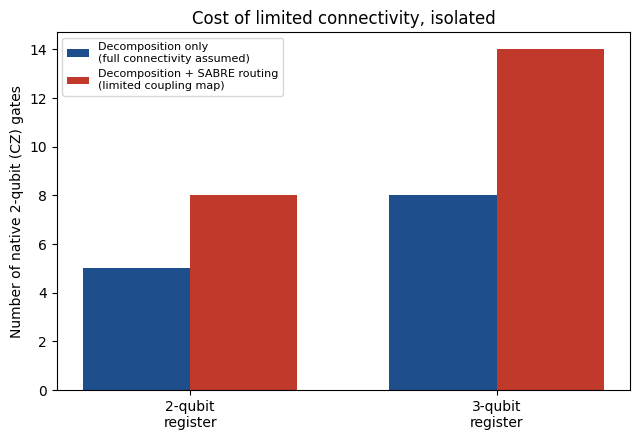

In [5]:
fig_data = []
for n in (2, 3):
    orig_cz = 0  # original circuit has 'cx'/'cry', not yet in native gates -- not directly comparable
    decomp_cz = decomposition_only[n].count_ops().get('cz', 0)
    full_cz = full_transpilation[n].count_ops().get('cz', 0)
    fig_data.append((n, decomp_cz, full_cz))

import matplotlib.pyplot as plt

labels = [f"{n}-qubit\nregister" for n, _, _ in fig_data]
decomp_vals = [d for _, d, _ in fig_data]
full_vals = [f for _, _, f in fig_data]

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(x - width/2, decomp_vals, width, label='Decomposition only\n(full connectivity assumed)', color='#1f4e8c')
ax.bar(x + width/2, full_vals, width, label='Decomposition + SABRE routing\n(limited coupling map)', color='#c0392b')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Number of native 2-qubit (CZ) gates')
ax.set_title('Cost of limited connectivity, isolated')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('transpilation_cost_breakdown.png', dpi=150)
plt.show()


### 5.5 Drawing the transpiled circuit

For reference, here's what the 2-qubit register case looks like after full transpilation — considerably less readable than Stage 3's clean diagram, which is itself part of the point: the hardware-ready circuit is a strictly less intuitive object than the algorithm-level one we've been reasoning about so far.


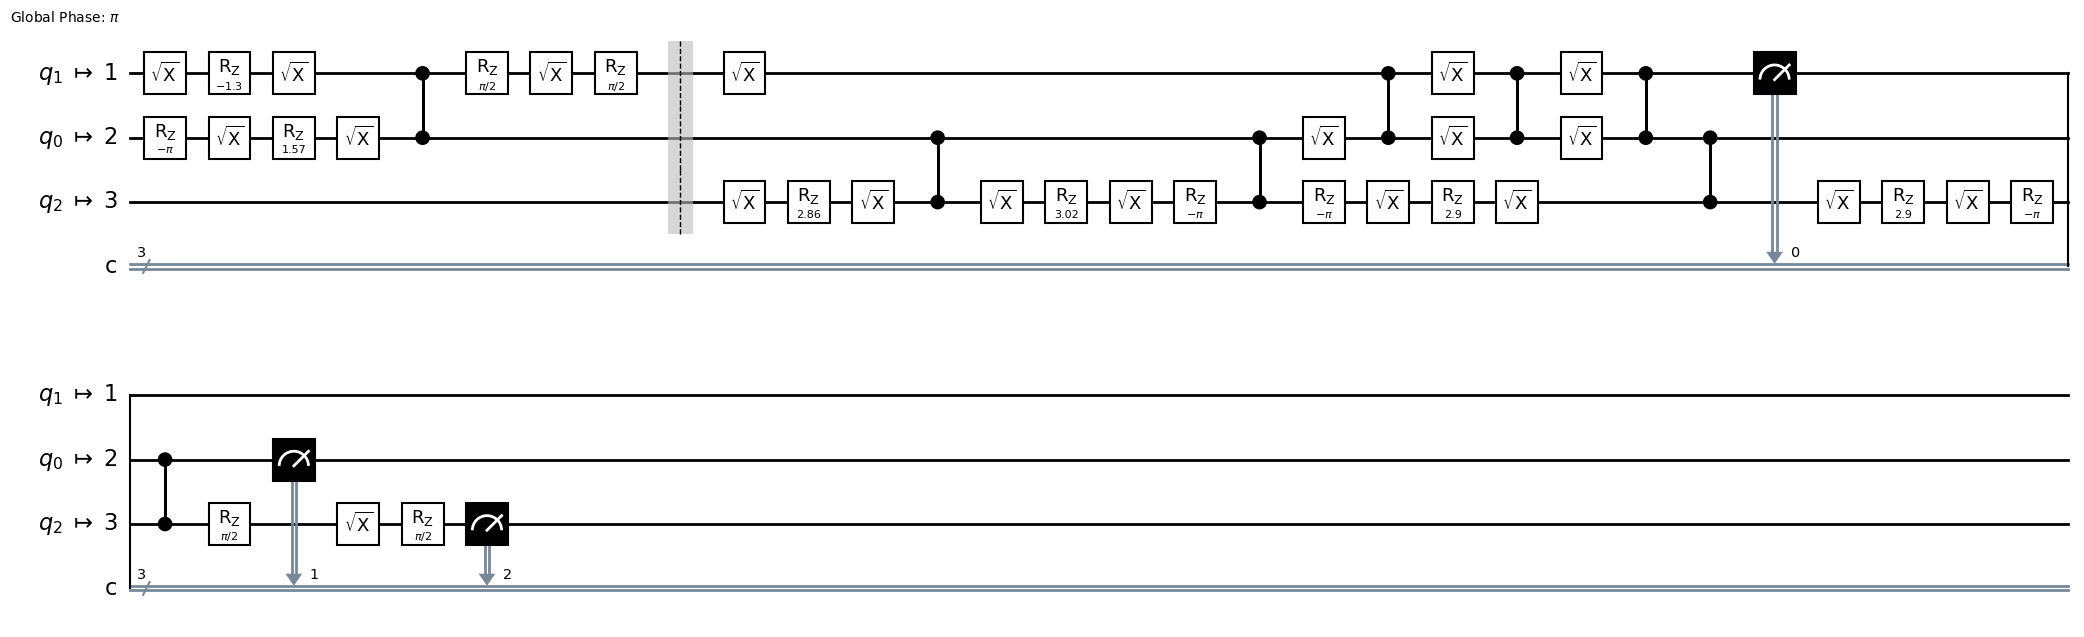

In [6]:
fig = full_transpilation[2].draw('mpl', style={'name': 'bw'}, fold=30)
fig.savefig('circuit_2q_transpiled.png', dpi=150, bbox_inches='tight')
fig


### 5.6 Does optimization level matter?

Qiskit's `transpile()` accepts an `optimization_level` (0-3), trading compile time for more aggressive gate cancellation and smarter routing search. We check whether pushing to the highest level meaningfully changes our results.


In [7]:
for level in (0, 1, 2, 3):
    tqc = transpile(circuits[2], coupling_map=coupling_maps[2], basis_gates=NATIVE_GATES,
                     layout_method='sabre', routing_method='sabre',
                     optimization_level=level, seed_transpiler=7)
    print(f"optimization_level={level}: depth={tqc.depth():>3}, "
          f"gates={dict(tqc.count_ops())}")


optimization_level=0: depth= 66, gates={'rz': 41, 'sx': 30, 'cz': 8, 'measure': 3, 'barrier': 1}
optimization_level=1: depth= 33, gates={'sx': 20, 'rz': 14, 'cz': 8, 'measure': 3, 'barrier': 1}
optimization_level=2: depth= 31, gates={'sx': 18, 'rz': 15, 'cz': 8, 'x': 3, 'measure': 3, 'barrier': 1}
optimization_level=3: depth= 31, gates={'sx': 18, 'rz': 15, 'cz': 8, 'x': 3, 'measure': 3, 'barrier': 1}


### 5.7 Saving the transpiled circuits for Stages 6-7

Qiskit circuits aren't naturally JSON-serializable, so we save them using Qiskit's native **QPY** binary format, alongside a JSON file recording the metadata (depth, gate counts, coupling map used) that later stages and the written report will want to reference.


In [8]:
import qiskit.qpy as qpy

with open("transpiled_circuits.qpy", "wb") as f:
    qpy.dump([full_transpilation[2], full_transpilation[3]], f)

transpilation_metadata = {}
for n in (2, 3):
    orig = circuits[n]
    tqc = full_transpilation[n]
    transpilation_metadata[f"{n}_qubit"] = {
        "original_depth": orig.depth(),
        "original_gate_counts": dict(orig.count_ops()),
        "transpiled_depth": tqc.depth(),
        "transpiled_gate_counts": dict(tqc.count_ops()),
        "coupling_map_edges": list(coupling_maps[n].get_edges()),
        "native_gates": NATIVE_GATES,
    }

with open("stage05_transpilation_results.json", "w") as f:
    json.dump(transpilation_metadata, f, indent=2)

print("Saved -> transpiled_circuits.qpy")
print("Saved -> stage05_transpilation_results.json")
print(json.dumps(transpilation_metadata, indent=2))


Saved -> transpiled_circuits.qpy
Saved -> stage05_transpilation_results.json
{
  "2_qubit": {
    "original_depth": 6,
    "original_gate_counts": {
      "ry": 3,
      "measure": 3,
      "cry": 2,
      "cx": 1,
      "barrier": 1
    },
    "transpiled_depth": 33,
    "transpiled_gate_counts": {
      "sx": 20,
      "rz": 14,
      "cz": 8,
      "measure": 3,
      "barrier": 1
    },
    "coupling_map_edges": [
      [
        0,
        1
      ],
      [
        1,
        2
      ],
      [
        2,
        3
      ]
    ],
    "native_gates": [
      "rz",
      "sx",
      "x",
      "cz"
    ]
  },
  "3_qubit": {
    "original_depth": 8,
    "original_gate_counts": {
      "ry": 4,
      "measure": 4,
      "cry": 3,
      "cx": 2,
      "barrier": 1
    },
    "transpiled_depth": 56,
    "transpiled_gate_counts": {
      "sx": 33,
      "rz": 23,
      "cz": 14,
      "measure": 4,
      "barrier": 1
    },
    "coupling_map_edges": [
      [
        0,
        1
      

## 6. What This Stage Produces

1. **Hardware-realistic circuits**, for both register sizes, expressed in a native gate set (`rz`, `sx`, `x`, `cz`) matching the base paper's actual device, and routed onto a connectivity-limited mock coupling map via SABRE.
2. **A clean separation of two overhead sources**: the unavoidable cost of basis-gate decomposition vs. the *avoidable-with-better-connectivity* cost of SWAP routing — quantified directly in extra two-qubit gates.
3. **Confirmation that SABRE optimizes structure only** — depth and gate count improve smoothly with `optimization_level`, but nothing in this process has looked at, or could look at, actual hardware error rates.
4. **`transpiled_circuits.qpy` / `stage05_transpilation_results.json`** — the circuits Stage 6 will attempt to retune under a simulated noise model, and Stage 7 will execute.


## 7. What's Next

**Stage 6 — Hardware / Noise Retuning (`06_hardware_retuning.ipynb`):** this is where the base paper's central finding — and this project's core novelty — actually gets tested. A Qiskit noise model (readout error + depolarizing channels) will be attached to a simulator standing in for real hardware, and the transpiled circuits built here will be run through it. The Stage 4 angles, retrained under perfect, noiseless conditions, are expected to **no longer produce the right distribution** once real noise is present — exactly the "in-situ invalidation of angles" gap identified in `00_overview.ipynb` §2. Two fixes will then be compared head to head:

- **Stage 6A (baseline):** a manual, brute-force angle grid-sweep — reproducing the base paper's own approach.
- **Stage 6B (novelty):** an automated closed-loop SPSA/Bayesian-optimization retuning process that searches for corrected angles directly against the noisy simulator, minimizing Hellinger distance to the target — the scalable alternative this project set out to build.

---
*Next: → `06_hardware_retuning.ipynb`*
